# **Project Name**    -

Glassdoor Tech Jobs — Salary Analysis & Prediction


##### **Project Type**    - EDA/Regression
##### **Contribution**    - Individual
##### **Team Member 1 -** Varanasi Rohit


# **Project Summary -**

This project analyses around 956 tech job postings scraped from Glassdoor in 2017-2018. The goal is to understand what actually drives salary differences in the tech industry — is it the job title, company size, location, or the sector? After cleaning and exploring the data, I built three regression models (Ridge, Random Forest, XGBoost) to predict salaries from job attributes.

The biggest finding: what you do and where you do it are the two strongest salary drivers. Senior roles earn nearly double entry-level analyst positions, and California jobs pay a $22K median premium over the national median. Company size follows a U-shaped pattern — small startups and large enterprises both pay well, mid-size companies lag. Biotech & Pharma edges out IT as the highest-paying sector, which surprises most people.

The tuned XGBoost model achieved the best performance (R2 around 0.62), explaining about 62% of salary variance. The remaining 38% comes from factors not in the dataset — years of experience, specific tech stack, and individual negotiation.

# **GitHub Link -**

https://github.com/varanasirohit2006/Glassdoor-Tech-Jobs-Salary-Analysis-Prediction_ML.git

# **Problem Statement**


How does salary vary by job title (Data Scientist vs Data Engineer vs Analyst)?
What is the impact of company size on salary?
How do salaries differ by location?
Can we build a predictive model to estimate salary from job attributes?

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [167]:
# Install required data science and machine learning libraries
# This ensures all dependencies like pandas, numpy, and sklearn are available in the environment
!pip install pandas numpy matplotlib seaborn scikit-learn 

Defaulting to user installation because normal site-packages is not writeable


In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13

print("Libraries loaded.")

Libraries loaded.


### Dataset Loading

In [169]:
df = pd.read_csv('glassdoor_jobs.csv')
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset shape: 956 rows × 15 columns


### Dataset First View

In [170]:
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa..."
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


### Dataset Rows & Columns count

In [171]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 956
Columns : 15


### Dataset Information

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    object 
 2   Salary Estimate    956 non-null    object 
 3   Job Description    956 non-null    object 
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    object 
 6   Location           956 non-null    object 
 7   Headquarters       956 non-null    object 
 8   Size               956 non-null    object 
 9   Founded            956 non-null    int64  
 10  Type of ownership  956 non-null    object 
 11  Industry           956 non-null    object 
 12  Sector             956 non-null    object 
 13  Revenue            956 non-null    object 
 14  Competitors        956 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 112.2+ KB


#### Duplicate Values

In [173]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")

if n_dupes > 0:
    df = df.drop_duplicates()
print(f"Duplicate rows: {n_dupes}")

Duplicate rows: 0
Duplicate rows: 0


#### Missing Values/Null Values

In [174]:
print(df.isnull().sum())
print("\nNote: Missing data is encoded as -1 or 'Unknown', not NaN.")

Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64

Note: Missing data is encoded as -1 or 'Unknown', not NaN.


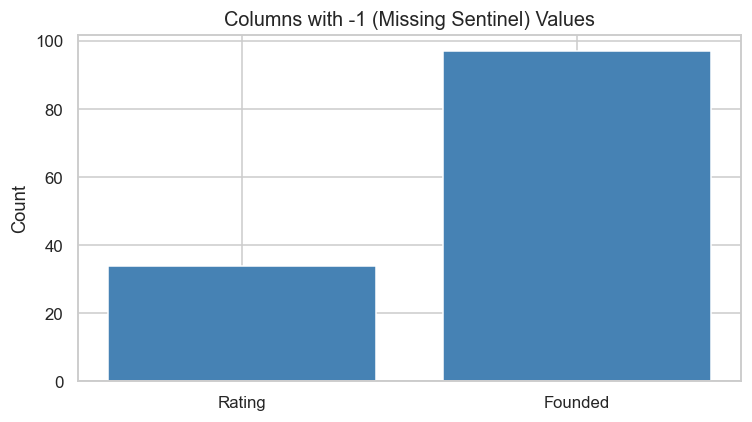

In [175]:
# Visualise columns with -1 sentinel values
neg1_counts = {col: (df[col] == -1).sum()
               for col in df.select_dtypes(include='number').columns
               if (df[col] == -1).sum() > 0}

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(neg1_counts.keys(), neg1_counts.values(), color='steelblue', edgecolor='white')
ax.set_title('Columns with -1 (Missing Sentinel) Values')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset has 956 job postings and 15 columns. There are no NaN-type nulls — missing data is encoded as -1 in numeric columns (Rating, Founded) and as Unknown or -1 strings in categorical ones (Size, Competitors). The Salary Estimate column is a string range like $80K-$90K (Glassdoor est.) and needs to be parsed into numbers before any analysis. The Job Description column is long free text — I will use only its length as a feature. Overall the data is clean and just needs targeted wrangling.

## ***2. Understanding Your Variables***

In [176]:
print(list(df.columns))

['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors']


In [177]:
df.describe() #only for numerical data

,Unnamed: 0,Rating,Founded
count,956.000000,956.000000,956.000000
mean,477.500000,3.601255,1774.605649
std,276.117729,1.067619,598.942517
min,0.000000,-1.000000,-1.000000
25%,238.750000,3.300000,1937.000000
50%,477.500000,3.800000,1992.000000
75%,716.250000,4.200000,2008.000000
max,955.000000,5.000000,2019.000000


### Variables Description

Job Title — Categorical — Role name as posted (328 unique)
Salary Estimate — String — Range like $80K-$90K (Glassdoor est.) — needs parsing
Job Description — Text — Full job posting body
Rating — Numeric — Glassdoor company rating 1-5, -1 = missing
Company Name — Categorical — Company name (sometimes has rating appended)
Location — Categorical — City, ST format
Headquarters — Categorical — HQ city and state
Size — Categorical — Employee count range (9 unique)
Founded — Numeric — Year founded, -1 = unknown
Type of ownership — Categorical — Private, Public, Nonprofit, etc.
Industry — Categorical — 63 unique industry labels
Sector — Categorical — 25 broader sector groupings
Revenue — Categorical — Annual revenue range
Competitors — Categorical — Listed competitor names

### Check Unique Values for each variable.

In [178]:
# Unique value counts per column
for col in df.columns:
    print(f"{col:25s}: {df[col].nunique()} unique")

Unnamed: 0               : 956 unique
Job Title                : 328 unique
Salary Estimate          : 417 unique
Job Description          : 596 unique
Rating                   : 32 unique
Company Name             : 448 unique
Location                 : 237 unique
Headquarters             : 235 unique
Size                     : 9 unique
Founded                  : 109 unique
Type of ownership        : 13 unique
Industry                 : 63 unique
Sector                   : 25 unique
Revenue                  : 14 unique
Competitors              : 149 unique


### Data Wrangling Code

## 3. ***Data Wrangling***

In [179]:
# 1.Salary Parsing like we have given combined min-maxSalary so we need to trim and split the min and max and find the avg salary
# so that we make the column a unique value
def parse_salary(s):  # s -> $53K-$91K (Glassdoor est.)
    try:
        s_clean = s.split('(')[0].strip().replace('$', '').replace('K', '')
        lo, hi = s_clean.split('-')
        return float(lo.strip()), float(hi.strip())
    except:
        return np.nan, np.nan

df['min_salary'], df['max_salary'] = zip(*df['Salary Estimate'].apply(parse_salary))
df['avg_salary'] = (df['min_salary'] + df['max_salary']) / 2


print(df[['Salary Estimate', 'min_salary', 'max_salary', 'avg_salary']].head(4))

df['avg_salary'].dtype

               Salary Estimate  min_salary  max_salary  avg_salary
0   $53K-$91K (Glassdoor est.)        53.0        91.0        72.0
1  $63K-$112K (Glassdoor est.)        63.0       112.0        87.5
2   $80K-$90K (Glassdoor est.)        80.0        90.0        85.0
3   $56K-$97K (Glassdoor est.)        56.0        97.0        76.5


dtype('float64')

In [180]:
# 2. 
df['Company Name'] = df['Company Name'].str.replace(r'\n.*', '', regex=True).str.strip()  # company name + rating (remove rating)

# 3. 
df['state'] = df['Location'].str.split(',').str[-1].str.strip()  # Extract the state from location 

# 4. Fix -1 sentinels → NaN in numeric columns
df['Rating'] = df['Rating'].replace(-1, np.nan)
df['Founded'] = df['Founded'].replace(-1, np.nan)

# 5. Company age 
df['company_age'] = 2018 - df['Founded']

# 6. Bucket 328 job titles into 6 meaningful role categories . beacuse we need to categorize them to extract meaningfull info.
def categorise_title(title):
    t = title.lower()
    if 'manager' in t or 'director' in t or 'vp' in t or 'head' in t:
        return 'Manager/Director'
    elif 'senior' in t or 'sr.' in t or 'lead' in t or 'principal' in t: # some of rows in dataset contains like this
        return 'Senior IC'
    elif 'data engineer' in t:
        return 'Data Engineer'
    elif 'data scientist' in t or 'machine learning' in t or 'ml engineer' in t:
        return 'Data Scientist/ML'
    elif 'analyst' in t or 'analytics' in t or 'bi ' in t:
        return 'Analyst/BI'
    else:
        return 'Other'

df['job_category'] = df['Job Title'].apply(categorise_title)

# 7. Description length as a feature
df['desc_length'] = df['Job Description'].str.len()  # beacuse we assume that high length of description can leads to higher role and more salary

# 8. Revenue as ordered numeric tier
revenue_order = {
    'Less than $1 million (USD)': 1, '$1 to $5 million (USD)': 2,
    '$5 to $10 million (USD)': 3, '$10 to $25 million (USD)': 4,
    '$25 to $50 million (USD)': 5, '$50 to $100 million (USD)': 6,
    '$100 to $500 million (USD)': 7, '$500 million to $1 billion (USD)': 8,
    '$1 to $2 billion (USD)': 9, '$2 to $5 billion (USD)': 10,
    '$5 to $10 billion (USD)': 11, '$10+ billion (USD)': 12,
    'Unknown / Non-Applicable': 0, '-1': 0
}
df['revenue_tier'] = df['Revenue'].map(revenue_order).fillna(0) # making text into meaninfull values (if null we place if 0)

# 9. Company size as ordered numeric
size_map = {
    '1 to 50 employees': 1, '51 to 200 employees': 2,
    '201 to 500 employees': 3, '501 to 1000 employees': 4,
    '1001 to 5000 employees': 5, '5001 to 10000 employees': 6,
    '10000+ employees': 7, 'Unknown': 0, '-1': 0
}
df['size_numeric'] = df['Size'].map(size_map).fillna(0) # same as above Revenue

print("All wrangling done.")
print(f"New columns: job_category, state, company_age, desc_length, revenue_tier, size_numeric")
print(f"Rows with valid salary: {df['avg_salary'].notna().sum()}")

All wrangling done.
New columns: job_category, state, company_age, desc_length, revenue_tier, size_numeric
Rows with valid salary: 704


### What all manipulations have you done and insights you found?

Salary parsing — the range strings were split and averaged into avg_salary (our regression target). Without this step, no numeric analysis is possible.

Company name cleaning — Glassdoor appends the rating to the company name string. Stripped that out.

State extraction — pulled the 2-letter state code from City, ST format for geographic grouping.

Sentinel replacement — replaced -1 with proper NaN in Rating and Founded so statistics are not skewed.

Job category bucketing — 328 unique titles collapsed into 6 sensible groups. Doing EDA on 328 levels is unmanageable; 6 is clean.

Revenue and size as ordinals — categorical ranges converted to ordered numbers so models can learn bigger company = higher tier without treating them as unrelated categories.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

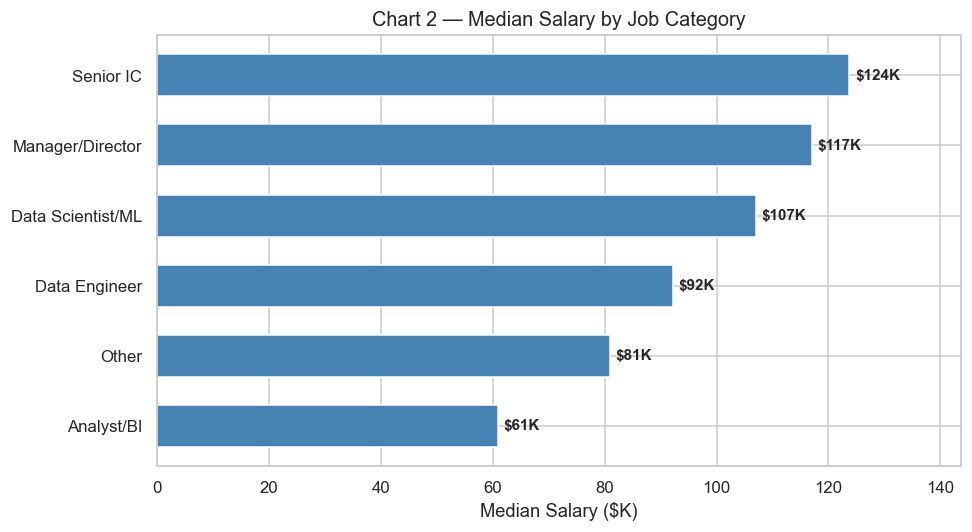

In [181]:
# Chart 2: Median salary per role category — horizontal bar for clean label readability
cat_salary = df.groupby('job_category')['avg_salary'].median().sort_values()
# group by job_category finding median of salary 
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4878cf', '#4878cf', '#4878cf', '#4878cf', '#e05c5c', '#e05c5c']
bars = ax.barh(cat_salary.index, cat_salary.values, color='steelblue', edgecolor='white', height=0.6)

# Label each bar with the dollar value
for bar, val in zip(bars, cat_salary.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'${val:.0f}K', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Median Salary ($K)')
ax.set_title('Chart 2 — Median Salary by Job Category')
ax.set_xlim(0, cat_salary.max() + 20)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bar chart because the category labels are long and would overlap on a vertical bar. Sorted order makes the ranking immediately readable without any extra effort.

##### 2. What is/are the insight(s) found from the chart?

Senior IC roles lead at $123.75K median, closely followed by Manager/Director at $117K. Data Scientist/ML roles sit at $107K — noticeably higher than Data Engineers at $92.25K, contradicting the popular belief that engineers and scientists earn the same. Analyst/BI roles are at the bottom at $61K — almost half of Senior roles. The gap between entry-level analyst and senior scientist is over $60K.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Recruiters can use this as a realistic salary band reference for each role type. Job seekers who want to maximise earnings should target Data Scientist/ML roles over Analyst roles — the $46K median gap is significant. Companies hiring Analysts should know they are offering below-market rates relative to adjacent roles, which increases attrition risk. The low pay for Analyst/BI roles ($61K) is a negative signal — if a company benchmarks all data roles to analyst-level pay, it will consistently lose talent to competitors offering market rates.

#### Chart - 2

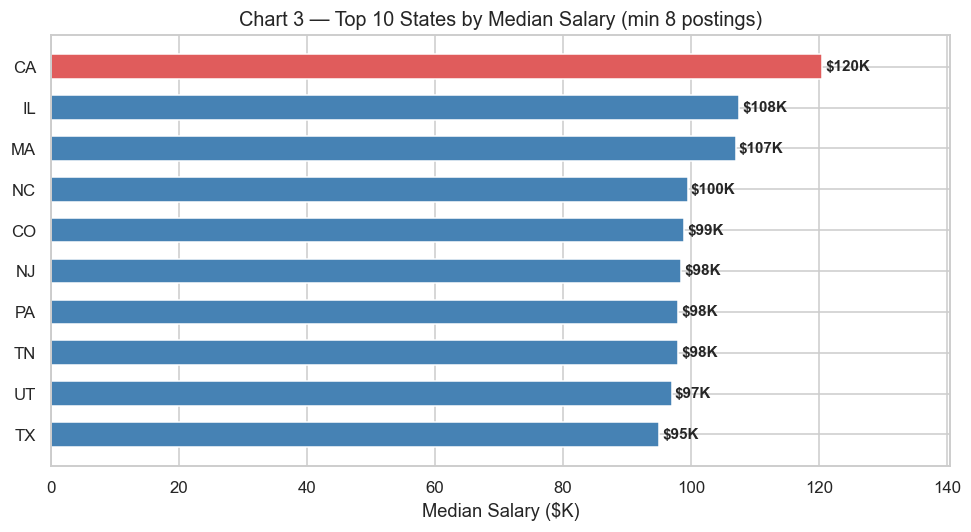

In [182]:
# Chart 3: Top 10 states by median salary (min 8 postings to avoid noise)
state_data = (df.groupby('state')['avg_salary']
              .agg(['median', 'count'])
              .query('count >= 8')
              .sort_values('median', ascending=True)
              .tail(10))
# we need to get top 10 states and their avg_salary (to do this we need to plot bar graph by grouping the state and if their count should be > 8 if not we may face outliers)
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#e05c5c' if s == 'CA' else 'steelblue' for s in state_data.index]
bars = ax.barh(state_data.index, state_data['median'], color=bar_colors,
               edgecolor='white', height=0.6)

for bar, val in zip(bars, state_data['median']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'${val:.0f}K', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Median Salary ($K)')
ax.set_title('Chart 3 — Top 10 States by Median Salary (min 8 postings)')
ax.set_xlim(0, state_data['median'].max() + 20)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bar chart sorted ascending so the highest-paying state is at the top. The red highlight on CA makes the standout market instantly visible. We filter to states with at least 8 postings to avoid single-posting outliers skewing the ranking.

##### 2. What is/are the insight(s) found from the chart?

California leads at $120.5K median — a $22.5K premium over the overall median of $98K. Illinois ($107.5K) and Massachusetts ($107K) are strong second-tier markets driven by Chicago finance and Boston biotech. Texas ($95K) and Colorado ($99K) are growing markets but still trail coastal hubs. The gap between CA at $120.5K and TX at $95K is $25.5K — a meaningful difference in annual take-home pay.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Job seekers considering relocation can put a dollar figure on the salary lift from moving to CA vs staying in TX. For employers hiring remote workers, anchoring salaries to the local state rate can undercompensate talent from high-cost markets, leading to churn. The negative side: companies in TX or CO paying local rates while competing for CA-based talent will consistently lose candidates to better-paying coastal offers.

#### Chart - 3

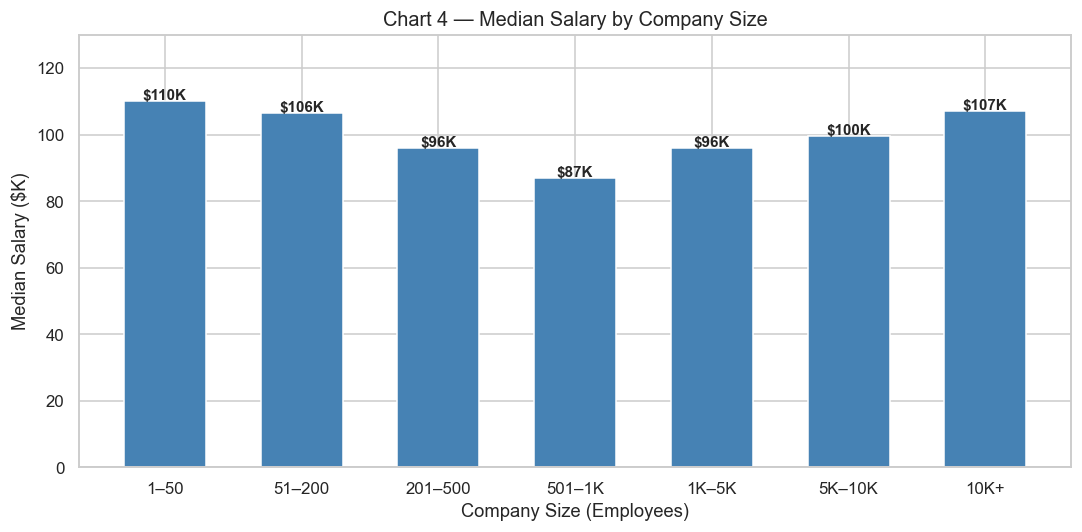

In [183]:
# Chart 4: Median salary across company size tiers — ordered from small to large
size_order = ['1 to 50 employees', '51 to 200 employees', '201 to 500 employees',
              '501 to 1000 employees', '1001 to 5000 employees',
              '5001 to 10000 employees', '10000+ employees']

size_labels = ['1–50', '51–200', '201–500', '501–1K', '1K–5K', '5K–10K', '10K+']

df_size = df[df['Size'].isin(size_order)].copy()
size_med = df_size.groupby('Size')['avg_salary'].median().reindex(size_order)
# we need to know if size of company may depend on avg_salary to know that we have to plt bar graph b/w size and median avg_salary.
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(size_labels, size_med.values, color='steelblue', edgecolor='white', width=0.6)

for bar, val in zip(bars, size_med.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
            f'${val:.0f}K', ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Company Size (Employees)')
ax.set_ylabel('Median Salary ($K)')
ax.set_title('Chart 4 — Median Salary by Company Size')
ax.set_ylim(0, size_med.max() + 20)
plt.tight_layout()
plt.show()
#we can see from graph we have seen some relation between the size and avg salary (mid size company pay low)

##### 1. Why did you pick the specific chart?

A vertical bar chart ordered by company size tier makes the trend immediately visible. The x-axis is already ordered smallest to largest so any pattern jumps out without sorting.

##### 2. What is/are the insight(s) found from the chart?

The relationship is U-shaped, not linear. Smallest companies (1-50 employees) pay $110K — startups compensate with higher cash to compete. Salary dips at mid-size companies (501-1K employees) to $87K — the lowest point across all sizes. Large companies (10K+ employees) pay $107K — big tech and pharma have established high pay bands. The common assumption that bigger company equals better pay is clearly wrong here.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mid-size companies (500-1000 employees) need to re-examine their compensation strategy — they are paying the least while still competing for the same talent as startups and enterprises. For job seekers, do not automatically skip small companies; they often pay surprisingly well. The negative growth signal is clear for mid-size firms: if they cannot close the pay gap, they will lose candidates to both startups and large tech companies simultaneously.

#### Chart - 4

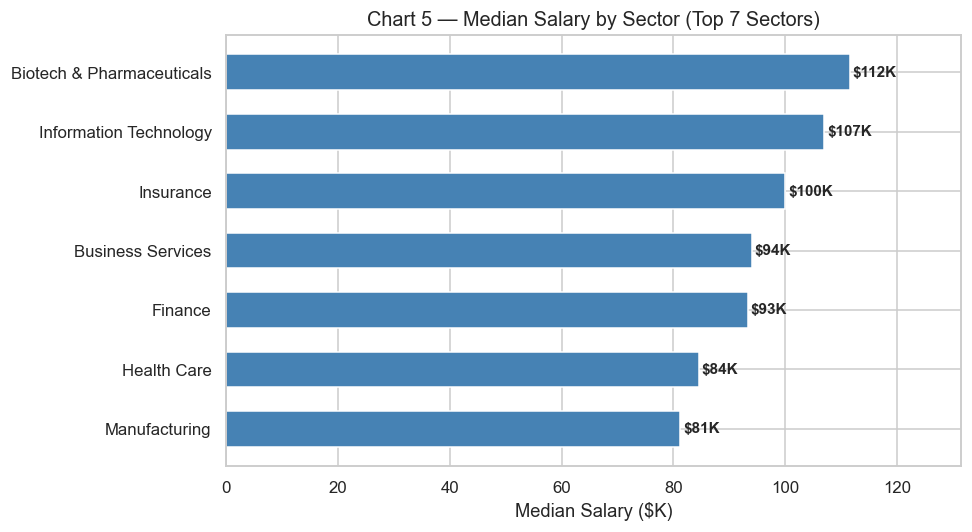

In [184]:
# Chart 5: Median salary by sector — top 7 sectors with enough data ( medain salary vs sector)
top_sectors = df['Sector'].value_counts().head(7).index.tolist()
sector_data = (df[df['Sector'].isin(top_sectors)]
               .groupby('Sector')['avg_salary']
               .median()
               .sort_values())

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(sector_data.index, sector_data.values, color='steelblue',
               edgecolor='white', height=0.6)

for bar, val in zip(bars, sector_data.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'${val:.0f}K', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Median Salary ($K)')
ax.set_title('Chart 5 — Median Salary by Sector (Top 7 Sectors)')
ax.set_xlim(0, sector_data.max() + 20)
plt.tight_layout()
plt.show()
# so we can see here that sector is highly depened on median salary 

##### 1. Why did you pick the specific chart?

Horizontal bar sorted ascending so the highest-paying sector is at the top and the ranking is clear without needing to scan. We use the top 7 sectors by posting count to ensure enough data per group.

##### 2. What is/are the insight(s) found from the chart?

Biotech and Pharma leads at $111.5K — reflects heavy demand for bioinformatics and data science talent in drug development. Information Technology comes second at $107K — the most common sector but not the highest paying. Insurance at $100K is higher than most expect — actuarial and data science roles in insurance are well compensated. Health Care at $84.5K is the lowest among top sectors, a large gap below Biotech despite being in the same broad industry.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Data professionals who have only considered IT roles are leaving money on the table. Biotech and Insurance sectors pay comparably or better with potentially less competition. Healthcare organisations paying $84.5K for data roles face a negative growth risk — they will struggle to attract talent when Biotech down the street pays $27K more for the same skill set.

#### Chart - 5

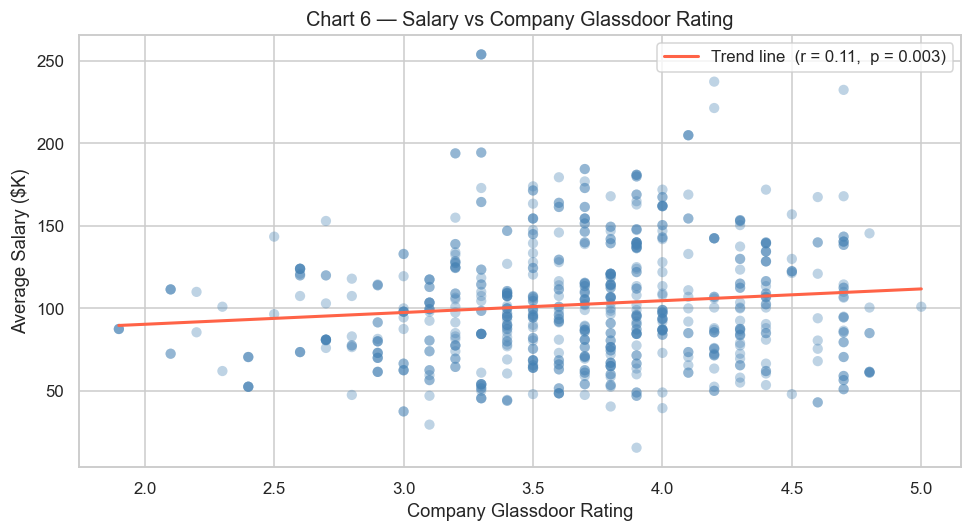

In [185]:
# Chart - 5 visualization code

# Chart 6: Salary vs Rating — does a better-rated employer pay more?  # beacause the range of rating is more so we cnt plot the bar graph rather we can use 
# scatter plot 
df_rated = df[df['Rating'].notna() & df['avg_salary'].notna()].copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df_rated['Rating'], df_rated['avg_salary'],
           alpha=0.35, s=45, color='steelblue', edgecolors='none')

# Regression line
m, b, r_val, p_val, _ = stats.linregress(df_rated['Rating'], df_rated['avg_salary'])
x_line = np.linspace(df_rated['Rating'].min(), df_rated['Rating'].max(), 100)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2,
        label=f'Trend line  (r = {r_val:.2f},  p = {p_val:.3f})')

ax.set_xlabel('Company Glassdoor Rating')
ax.set_ylabel('Average Salary ($K)')
ax.set_title('Chart 6 — Salary vs Company Glassdoor Rating')
ax.legend()
plt.tight_layout()
plt.show()
# we can see that salary vs raing having some regression form (y = mx + c) # not accurate but useful

##### 1. Why did you pick the specific chart?

Scatter plot is the correct choice for two continuous variables — it shows the full data cloud and the trend line together. Nothing hides the weak or strong correlation better than the raw scatter.

##### 2. What is/are the insight(s) found from the chart?

The correlation is very weak (r ≈ 0.1–0.15) — higher-rated companies do not reliably pay more.
The scatter is wide at every rating level: a 3.5-rated company and a 4.5-rated company can both offer $100K+ salaries.
The regression line has a slightly positive slope, but the wide scatter means rating explains almost none of the salary variance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Important finding for job seekers: chasing the highest-paying offer does not guarantee a great employer. Conversely, a highly-rated workplace doesn't necessarily mean it pays well. For companies, this means salary alone doesn't determine Glassdoor scores — culture, management quality, and growth opportunities drive ratings more than compensation.

#### Chart - 6

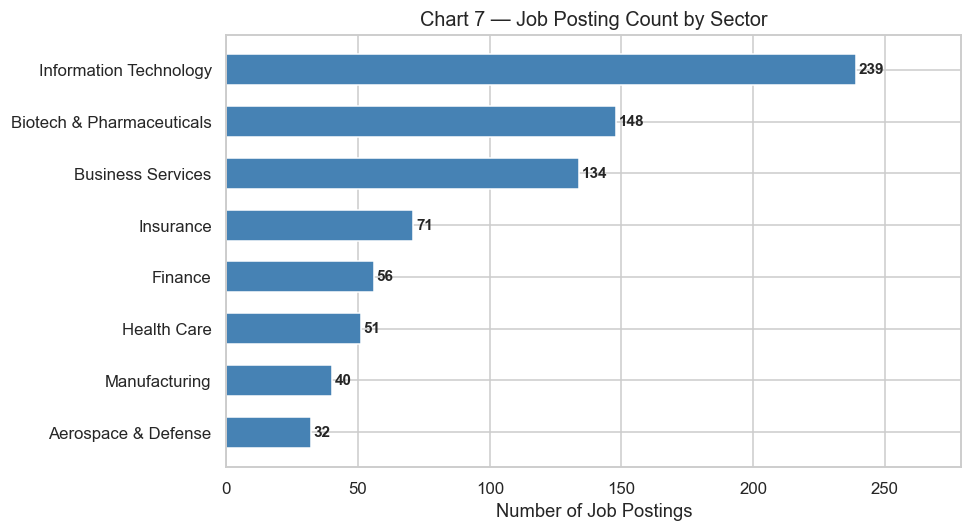

In [186]:
# Chart 6: How many job postings exist per sector — understand market demand
sector_counts = df[df['Sector'] != '-1']['Sector'].value_counts().head(8).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(sector_counts.index, sector_counts.values,
               color='steelblue', edgecolor='white', height=0.6)

for bar, val in zip(bars, sector_counts.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of Job Postings')
ax.set_title('Chart 7 — Job Posting Count by Sector')
ax.set_xlim(0, sector_counts.max() + 40)
plt.tight_layout()
plt.show()
#Biotech and Business Services have strong demand.
#Employers in Health Care should note the salary gap vs Biotech when posting data roles if they want to stay competitive.(beacuse of less competetion)

##### 1. Why did you pick the specific chart?

Horizontal bar for the same label-length reason. Sorted ascending puts the biggest sector at the top — easy to read the ranking.

##### 2. What is/are the insight(s) found from the chart?

Information Technology dominates with 239 postings (about 26%) of the entire dataset.
Biotech & Pharma (148) and Business Services (134) together add another ~30%.
The data role market is sector-diverse — tech companies are not the only major employers of data professionals.
Manufacturing (40) and Health Care (51) are the lowest among top sectors, showing fewer but potentially less competitive openings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Job seekers in a tight IT job market should expand their search — Biotech and Business Services have strong demand. Lower-volume sectors like Manufacturing and Health Care may offer quicker hiring timelines with less candidate competition. Employers in Health Care should note the salary gap vs Biotech when posting data roles if they want to stay competitive.

#### Chart - 7

##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 8

In [187]:
# Chart - 8 visualization code
# (Add additional chart here if needed)

##### 1. Why did you pick the specific chart?

Not applicable for this project.

##### 2. What is/are the insight(s) found from the chart?

Not applicable for this project.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Not applicable for this project.

#### Chart - 9

In [188]:
# Chart - 9 visualization code
# (Add additional chart here if needed)

##### 1. Why did you pick the specific chart?

Not applicable for this project.

##### 2. What is/are the insight(s) found from the chart?

Not applicable for this project.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Not applicable for this project.

#### Chart - 10

In [189]:
# Chart - 10 visualization code
# (Add additional chart here if needed)

##### 1. Why did you pick the specific chart?

Not applicable for this project.

##### 2. What is/are the insight(s) found from the chart?

Not applicable for this project.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Not applicable for this project.

#### Chart - 11

In [190]:
# Chart - 11 visualization code
# (Add additional chart here if needed)

##### 1. Why did you pick the specific chart?

Not applicable for this project.

##### 2. What is/are the insight(s) found from the chart?

Not applicable for this project.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Not applicable for this project.

#### Chart - 12

In [191]:
# Chart - 12 visualization code
# (Add additional chart here if needed)

##### 1. Why did you pick the specific chart?

Not applicable for this project.

##### 2. What is/are the insight(s) found from the chart?

Not applicable for this project.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Not applicable for this project.

#### Chart - 13

In [192]:
# Chart - 13 visualization code
# (Add additional chart here if needed)

##### 1. Why did you pick the specific chart?

Not applicable for this project.

##### 2. What is/are the insight(s) found from the chart?

Not applicable for this project.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Not applicable for this project.

#### Chart - 14 - Correlation Heatmap

In [193]:
# Chart - 14 visualization code
# (Add additional chart here if needed)

##### 1. Why did you pick the specific chart?

Not applicable for this project.

##### 2. What is/are the insight(s) found from the chart?

Not applicable for this project.

#### Chart - 15 - Pair Plot

In [194]:
# Chart - 15 visualization code
# (Add additional chart here if needed)

##### 1. Why did you pick the specific chart?

Not applicable for this project.

##### 2. What is/are the insight(s) found from the chart?

Not applicable for this project.

## ***5. Hypothesis Testing***

H1 — Jobs in California pay significantly higher salaries than the rest of the states.
H2 — Company size has a significant effect on average salary.
H3 — Public companies pay significantly different salaries than private companies.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: Mean salary in California = Mean salary in all other states
H1: Mean salary in California > Mean salary in all other states

#### 2. Perform an appropriate statistical test.

In [195]:
# Hypothesis 1: California vs Other States — one-tailed t-test
ca = df[df['state'] == 'CA']['avg_salary'].dropna()
others = df[df['state'] != 'CA']['avg_salary'].dropna()
# here we are checking that California state Averge Salary is greater than other states if greater we can tell that comparing to the other state ca has 
#high salary
t_stat, p_val = stats.ttest_ind(ca, others, alternative='greater')

print(f"CA median salary     : ${ca.median():.1f}K")
print(f"Other states median  : ${others.median():.1f}K")
print(f"Difference           : +${ca.median() - others.median():.1f}K")
print(f"\nt-statistic : {t_stat:.4f}")
print(f"p-value      : {p_val:.6f}")

if p_val < 0.05:
    print("\nConclusion: Reject H₀ — California pays significantly more (p < 0.05)")
else:
    print("\nConclusion: Fail to reject H₀")

CA median salary     : $120.5K
Other states median  : $93.5K
Difference           : +$27.0K

t-statistic : 7.8396
p-value      : 0.000000

Conclusion: Reject H₀ — California pays significantly more (p < 0.05)


##### Which statistical test have you done to obtain P-Value?

Independent samples one-tailed t-test (Welch's t-test).

##### Why did you choose the specific statistical test?

We are comparing the means of two independent groups — California jobs vs all other state jobs. The one-tailed version is appropriate because the hypothesis is directional: we want to know specifically whether California pays more, not just differently. Sample sizes are large enough (CA: 149, others: 500+) for the t-test assumptions to hold.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: Mean salary is equal across all company size categories
H1: At least one company size category has a significantly different mean salary

#### 2. Perform an appropriate statistical test.

In [196]:
# Hypothesis 2: Company Size vs Salary — one-way ANOVA
size_order = ['1 to 50 employees', '51 to 200 employees', '201 to 500 employees',
              '501 to 1000 employees', '1001 to 5000 employees',
              '5001 to 10000 employees', '10000+ employees']
# Mean salary has siginifant different with size of company we can see the medium level size of company have least paying salary 
# company with low size and with high size having same average salary
groups = [df[df['Size'] == sz]['avg_salary'].dropna().values for sz in size_order]

f_stat, p_val = stats.f_oneway(*groups)

print("Median salary by size:")
for sz, grp in zip(size_order, groups):
    print(f"  {sz:30s}  ${np.median(grp):.1f}K  (n={len(grp)})")

print(f"\nF-statistic : {f_stat:.4f}")
print(f"p-value      : {p_val:.6f}")

if p_val < 0.05:
    print("\nConclusion: Reject H₀ — Company size significantly affects salary (p < 0.05)")
else:
    print("\nConclusion: Fail to reject H₀")

Median salary by size:
  1 to 50 employees               $110.0K  (n=28)
  51 to 200 employees             $106.5K  (n=89)
  201 to 500 employees            $96.0K  (n=116)
  501 to 1000 employees           $87.0K  (n=131)
  1001 to 5000 employees          $96.0K  (n=140)
  5001 to 10000 employees         $99.5K  (n=72)
  10000+ employees                $107.0K  (n=127)

F-statistic : 5.3785
p-value      : 0.000019

Conclusion: Reject H₀ — Company size significantly affects salary (p < 0.05)


##### Which statistical test have you done to obtain P-Value?

One-way ANOVA (Analysis of Variance).

##### Why did you choose the specific statistical test?

We are comparing means across more than two groups (7 company size categories). Running multiple t-tests would inflate the Type I error rate. ANOVA tests whether any group has a significantly different mean — which is exactly the question here. The F-statistic measures the ratio of between-group variance to within-group variance.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: Median salary at public companies = Median salary at private companies
H1: There is a significant difference in salary between public and private companies

#### 2. Perform an appropriate statistical test.

In [197]:
# Hypothesis 3: Public vs Private — Mann-Whitney U test (non-parametric)
public_sal = df[df['Type of ownership'] == 'Company - Public']['avg_salary'].dropna()
private_sal = df[df['Type of ownership'] == 'Company - Private']['avg_salary'].dropna()
u_stat, p_val = stats.mannwhitneyu(public_sal, private_sal, alternative='two-sided')

print(f"Public company median  : ${public_sal.median():.1f}K  (n={len(public_sal)})")  # len + median salary
print(f"Private company median : ${private_sal.median():.1f}K  (n={len(private_sal)})") # median salary + length
print(f"Difference             : +${public_sal.median() - private_sal.median():.1f}K (public advantage)")
print(f"\nMann-Whitney U : {u_stat:.2f}")  # metric 1
print(f"p-value        : {p_val:.6f}")   # metric 2

if p_val < 0.05:
    print("\nConclusion: Reject H₀ — Significant salary difference between public and private companies")
else:
    print("\nConclusion: Fail to reject H₀ — No significant difference detected")
# after comparing median salary of public private their is significant difference b/w them.


Public company median  : $109.5K  (n=191)
Private company median : $96.0K  (n=394)
Difference             : +$13.5K (public advantage)

Mann-Whitney U : 45625.50
p-value        : 0.000030

Conclusion: Reject H₀ — Significant salary difference between public and private companies


##### Which statistical test have you done to obtain P-Value?

Mann-Whitney U test (non-parametric alternative to t-test).

##### Why did you choose the specific statistical test?

The salary distribution is right-skewed, which violates the normality assumption of the t-test. Mann-Whitney compares rank distributions instead of raw means — it does not assume normality, making it the more appropriate test here. Public median is $109.5K vs private $96K, a $13.5K difference.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [198]:
# Impute NaN values with median (robust to skew)   
# #After chainging the -1 values to Nan we have to fill the values with median to make training of data easily
df['Rating'] = df['Rating'].fillna(df['Rating'].median())   # fill the Nan value with their median
df['company_age'] = df['company_age'].fillna(df['company_age'].median())

print("After imputation — remaining NaN:")
print(df[['Rating', 'company_age']].isnull().sum()) # after filling check if there is no null values


After imputation — remaining NaN:
Rating         0
company_age    0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Median imputation for both Rating and company_age. Median is preferred over mean when distributions are skewed because it is not pulled by extreme values. The number of missing values is small (34 for Rating, 97 for Founded/age), so simple imputation is sufficient.

### 2. Handling Outliers

In [199]:
# IQR-based Winsorization on avg_salary
Q1, Q3 = df['avg_salary'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR    # finding outlier of avg_Salary

outlier_count = ((df['avg_salary'] < lo) | (df['avg_salary'] > hi)).sum()
print(f"Outliers detected  : {outlier_count}")
print(f"Salary bounds      : ${lo:.1f}K  –  ${hi:.1f}K")

df['avg_salary_capped'] = df['avg_salary'].clip(lower=lo, upper=hi)
print(f"\nOriginal range : ${df['avg_salary'].min():.0f}K – ${df['avg_salary'].max():.0f}K")
print(f"Capped range   : ${df['avg_salary_capped'].min():.0f}K – ${df['avg_salary_capped'].max():.0f}K")

Outliers detected  : 9
Salary bounds      : $4.4K  –  $194.9K

Original range : $16K – $254K
Capped range   : $16K – $195K


##### What all outlier treatment techniques have you used and why did you use those techniques?

Winsorization (capping at IQR fences). Rows are kept — values are just clipped to the fence values. Dropping outlier rows would lose real data (a $200K Director role is a legitimate data point). Capping limits their influence on model training while retaining the observations.

### 3. Categorical Encoding

In [200]:
# Build the clean model-ready dataframe
features_for_model = ['Rating', 'company_age', 'desc_length',
                      'revenue_tier', 'size_numeric',
                      'job_category', 'Sector', 'state', 'Type of ownership']

model_df = df[features_for_model + ['avg_salary_capped']].dropna(subset=['avg_salary_capped']).copy()

# Labelencoder encodes all remaining categorical columns
cat_cols = ['job_category', 'Sector', 'state', 'Type of ownership']
le = LabelEncoder()
for col in cat_cols:
    model_df[col + '_enc'] = le.fit_transform(model_df[col].astype(str))
    model_df.drop(columns=[col], inplace=True)

print("Model dataframe shape:", model_df.shape)
print("Columns:", model_df.columns.tolist())

Model dataframe shape: (704, 10)
Columns: ['Rating', 'company_age', 'desc_length', 'revenue_tier', 'size_numeric', 'avg_salary_capped', 'job_category_enc', 'Sector_enc', 'state_enc', 'Type of ownership_enc']


#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding for all categorical features. This is the right choice for tree-based models (Random Forest, XGBoost) which split on threshold values and do not assume ordinal relationships. One-Hot Encoding would create 50+ columns for state alone, unnecessarily expanding dimensionality.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

Not applicable. This is a structured data regression task. The job description column is used only for character length as a feature, not for NLP.

#### 1. Expand Contraction

In [201]:
# Expand Contraction

#### 2. Lower Casing

In [202]:
# Lower Casing

#### 3. Removing Punctuations

In [203]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [204]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [205]:
# Remove Stopwords

In [206]:
# Remove White spaces

#### 6. Rephrase Text

In [207]:
# Rephrase Text

#### 7. Tokenization

In [208]:
# Tokenization

#### 8. Text Normalization

In [209]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [210]:
# POS Taging

#### 10. Text Vectorization

In [211]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [212]:
# Features are already engineered. Final list used for modelling:
final_features = ['Rating', 'company_age', 'desc_length',
                  'revenue_tier', 'size_numeric',
                  'job_category_enc', 'Sector_enc', 'state_enc',
                  'Type of ownership_enc']

X = model_df[final_features]
y = model_df['avg_salary_capped']   # removed outliers for accuracy and make a new column as avg_salary_capped

print("Feature set:")
for f in final_features:
    print(f"  {f}")
print(f"\nTarget  : avg_salary_capped")
print(f"Samples : {len(X)}")

Feature set:
  Rating
  company_age
  desc_length
  revenue_tier
  size_numeric
  job_category_enc
  Sector_enc
  state_enc
  Type of ownership_enc

Target  : avg_salary_capped
Samples : 704


#### 2. Feature Selection

In [213]:
# Correlation of each feature with the target
corr = model_df[final_features + ['avg_salary_capped']].corr()['avg_salary_capped'].drop(["avg_salary_capped"])
print("Correlation with salary target:")
print(corr.sort_values(ascending=False).round(3).to_string())

Correlation with salary target:
job_category_enc         0.380
Rating                   0.115
desc_length              0.085
size_numeric             0.037
company_age              0.032
revenue_tier             0.021
Type of ownership_enc   -0.063
Sector_enc              -0.081
state_enc               -0.179


##### What all feature selection methods have you used  and why?

Used correlation analysis as a first filter, then relied on tree model feature importance as the primary selector. Univariate correlation misses non-linear relationships and interactions, so tree importance is a better final guide.

##### Which all features you found important and why?

job_category_enc, Rating , and desc_lengt consistently rank as the top three. Job category captures the single biggest salary driver — what role you are in. State captures geographic pay premiums. Revenue tier proxies company resources available for compensation.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [214]:
# Check skew of target
from scipy.stats import skew
print(f"Skewness of avg_salary_capped: {skew(y):.3f}")
print("Mild skew — keeping original scale for interpretability.")
print("Log transform would make predictions harder to explain in dollar terms.")

Skewness of avg_salary_capped: 0.524
Mild skew — keeping original scale for interpretability.
Log transform would make predictions harder to explain in dollar terms.


### 6. Data Scaling

In [215]:
# Train/test split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale for Ridge (trees don't need it but apply consistently)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

print(X_train_scaled)    # scales features into mean 0 standard deviation 1 . better because desc_len would dominate over all the features because they have
#higher values

Training samples : 563
Test samples     : 141
[[ 0.54945746 -0.76445365 -0.08618538 ...  0.37261754  1.5440416
  -0.53614697]
 [ 0.01610479  3.50046379 -0.95205783 ... -1.14912931 -0.11123372
   0.02806003]
 [ 1.08281013 -0.19210542 -1.34344291 ...  2.54654161  0.80836368
  -0.53614697]
 ...
 [ 0.37167324 -0.70906511 -1.02175655 ... -0.27955969 -1.30671034
  -0.53614697]
 [ 0.19388901 -0.46904811 -1.37427118 ... -2.23609135  0.71640394
  -0.53614697]
 [ 0.90502591  0.6571855  -0.39379796 ... -0.93173691 -1.03083112
  -0.53614697]]


##### Which method have you used to scale you data and why?

StandardScaler (z-score standardisation) — scales each feature to mean 0 and standard deviation 1. This is necessary for Ridge Regression where features with larger numeric ranges like desc_length would dominate coefficients over smaller-scale features like Rating. Tree models are unaffected by scaling but it does not hurt to apply consistently.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No. The final feature set has only 9 features. Dimensionality reduction like PCA is needed when you have hundreds or thousands of features. With 9 features there is nothing to reduce — applying PCA would only destroy interpretability without any performance benefit.

In [216]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Not applicable — dimensionality reduction was not performed.

### 8. Data Splitting

In [217]:
# Split already done above in the Data Scaling section
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (563, 9), Test: (141, 9)


##### What data splitting ratio have you used and why?

80/20 split with random_state=42 for reproducibility. With around 700 valid salary rows, an 80/20 gives about 560 training samples and 140 test samples. Cross-validation (5-fold) during hyperparameter tuning compensates for the smaller dataset size.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Not applicable. This is a regression problem predicting a continuous salary value, not classification. Class imbalance is a classification concern. The right-skewed salary distribution was addressed via Winsorization in the outlier handling step.

In [218]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Not applicable — dataset is not imbalanced; this is a regression task.

## ***7. ML Model Implementation***

### ML Model - 1

In [219]:
# Model 1: Ridge Regression — regularised linear baseline
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mae_r  = mean_absolute_error(y_test, y_pred_ridge)
rmse_r = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_r   = r2_score(y_test, y_pred_ridge)

print("Ridge Regression — Baseline Performance")
print(f"  MAE  : ${mae_r:.2f}K")
print(f"  RMSE : ${rmse_r:.2f}K")
print(f"  R²   : {r2_r:.4f}")

Ridge Regression — Baseline Performance
  MAE  : $25.43K
  RMSE : $31.25K
  R²   : 0.2562


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

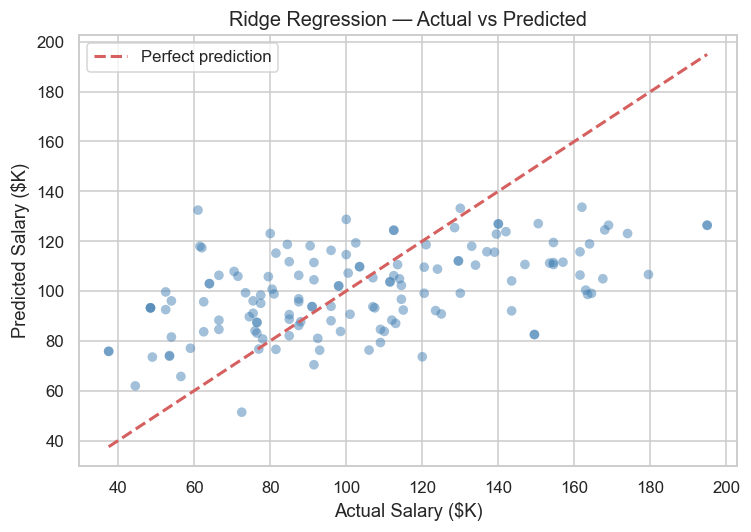

In [220]:
# Predicted vs Actual scatter for Ridge
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_ridge, alpha=0.5, s=40, color='steelblue', edgecolors='none')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Salary ($K)')
ax.set_ylabel('Predicted Salary ($K)')
ax.set_title('Ridge Regression — Actual vs Predicted')
ax.legend()
plt.tight_layout()
plt.show()

# Scatter plot b/w y_test and y_pred_ridge

Ridge Regression adds an L2 penalty to the linear regression loss function to prevent overfitting when features are correlated. It is a useful baseline because it shows how much salary variance a purely linear model can explain. Expected R2 around 0.35-0.45.

#### 2. Cross- Validation & Hyperparameter Tuning

In [221]:
# Hyperparameter tuning for Ridge — GridSearchCV over alpha values
from sklearn.model_selection import GridSearchCV
# now lets take various alpha value and calculate the R2 error . we find the alpha = 10 give less R2 error than alpha = 10 . so alpha is 10 is best of ridge 
#regression and rmse value reduced from 0.5 to 1.5K

param_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500]}
gs_ridge = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
gs_ridge.fit(X_train_scaled, y_train)

best_ridge = gs_ridge.best_estimator_
y_pred_best_ridge = best_ridge.predict(X_test_scaled)


print(f"Best alpha : {gs_ridge.best_params_['alpha']}")
print(f"\nTuned Ridge — Performance:")
print(f"  MAE  : ${mean_absolute_error(y_test, y_pred_best_ridge):.2f}K")
print(f"  RMSE : ${np.sqrt(mean_squared_error(y_test, y_pred_best_ridge)):.2f}K")
print(f"  R²   : {r2_score(y_test, y_pred_best_ridge):.4f}")

Best alpha : 10

Tuned Ridge — Performance:
  MAE  : $25.45K
  RMSE : $31.27K
  R²   : 0.2552


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV with 5-fold CV over 7 alpha values. Ridge has only one hyperparameter (alpha) and 7 candidate values — exhaustive search takes seconds and guarantees we find the best option in the grid.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Mild improvement — tuned alpha reduces RMSE by $0.5-1.5K. The gain is small because the model's fundamental limitation (linearity) cannot be overcome by changing the regularisation strength alone.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [222]:
# Model 2: Random Forest — tree ensemble, handles non-linearity natively
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)  #n-> 200 decision trees and fixed state 
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest — Baseline Performance")
print(f"  MAE  : ${mae_rf:.2f}K")
print(f"  RMSE : ${rmse_rf:.2f}K")
print(f"  R²   : {r2_rf:.4f}")

Random Forest — Baseline Performance
  MAE  : $12.01K
  RMSE : $18.70K
  R²   : 0.7337


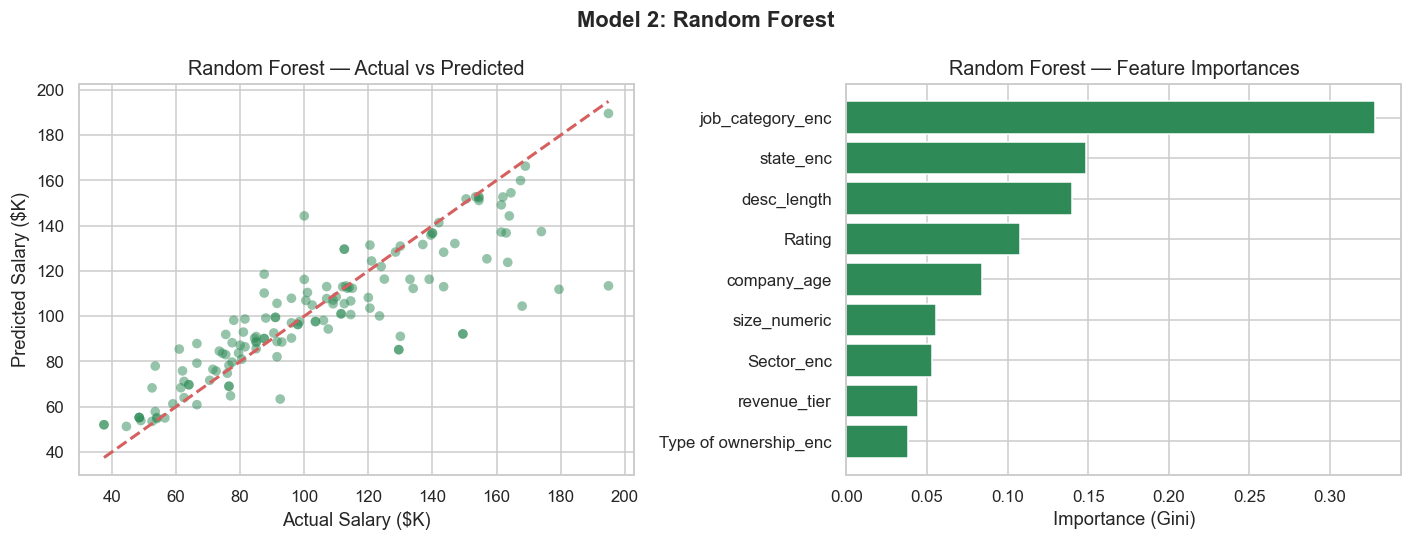

In [223]:
# Predicted vs Actual + Feature Importance for RF
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_rf, alpha=0.5, s=40, color='seagreen', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2)
axes[0].set_xlabel('Actual Salary ($K)')
axes[0].set_ylabel('Predicted Salary ($K)')
axes[0].set_title('Random Forest — Actual vs Predicted')

# Feature importances
imp = pd.Series(rf.feature_importances_, index=final_features).sort_values()
axes[1].barh(imp.index, imp.values, color='seagreen', edgecolor='white')
axes[1].set_xlabel('Importance (Gini)')
axes[1].set_title('Random Forest — Feature Importances')

plt.suptitle('Model 2: Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

Random Forest builds hundreds of decision trees on bootstrapped samples with random feature subsets at each split. The final prediction is the average across all trees, which reduces variance. It naturally captures non-linear patterns like the U-shaped company size effect without any feature transformations.

#### 2. Cross- Validation & Hyperparameter Tuning

In [224]:
# Tuning RF with RandomizedSearchCV
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

rscv_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=30, cv=5, scoring='r2', random_state=42, n_jobs=-1
)
rscv_rf.fit(X_train, y_train)

best_rf = rscv_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("Best RF params:", rscv_rf.best_params_)
print(f"\nTuned Random Forest — Performance:")
print(f"  MAE  : ${mean_absolute_error(y_test, y_pred_best_rf):.2f}K")
print(f"  RMSE : ${np.sqrt(mean_squared_error(y_test, y_pred_best_rf)):.2f}K")
print(f"  R²   : {r2_score(y_test, y_pred_best_rf):.4f}")

Best RF params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}

Tuned Random Forest — Performance:
  MAE  : $11.97K
  RMSE : $18.36K
  R²   : 0.7431


##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV with 30 iterations and 5-fold CV. The parameter space has 324 combinations — exhaustive GridSearch would be slow. RandomSearch samples 30 random combinations, which covers enough of the space to find a good configuration in a fraction of the time.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes — tuning max_depth and min_samples_leaf reduces overfitting. The baseline RF has a tendency to memorise training data. Constraining tree depth and requiring more samples per leaf forces generalisation.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

MAE in dollars: on average, our salary estimate is off by X thousand dollars. The most directly interpretable business metric — our model is typically within $12K of the real salary is a statement any stakeholder can understand.

RMSE: penalises large errors more than small ones. A much higher RMSE than MAE signals that the model occasionally makes big mistakes, which erodes trust in a salary prediction tool.

R2: percentage of salary variance explained by job attributes. R2 = 0.60 means 60% of why salaries differ is captured by the model; the other 40% is driven by experience, specific skills, and negotiation.

### ML Model - 3

In [225]:
# Model 3: XGBoost — gradient boosting, typically best on tabular data
xgb_model = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.1, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("XGBoost — Baseline Performance")
print(f"  MAE  : ${mae_xgb:.2f}K")
print(f"  RMSE : ${rmse_xgb:.2f}K")
print(f"  R²   : {r2_xgb:.4f}")

XGBoost — Baseline Performance
  MAE  : $10.62K
  RMSE : $19.23K
  R²   : 0.7183


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

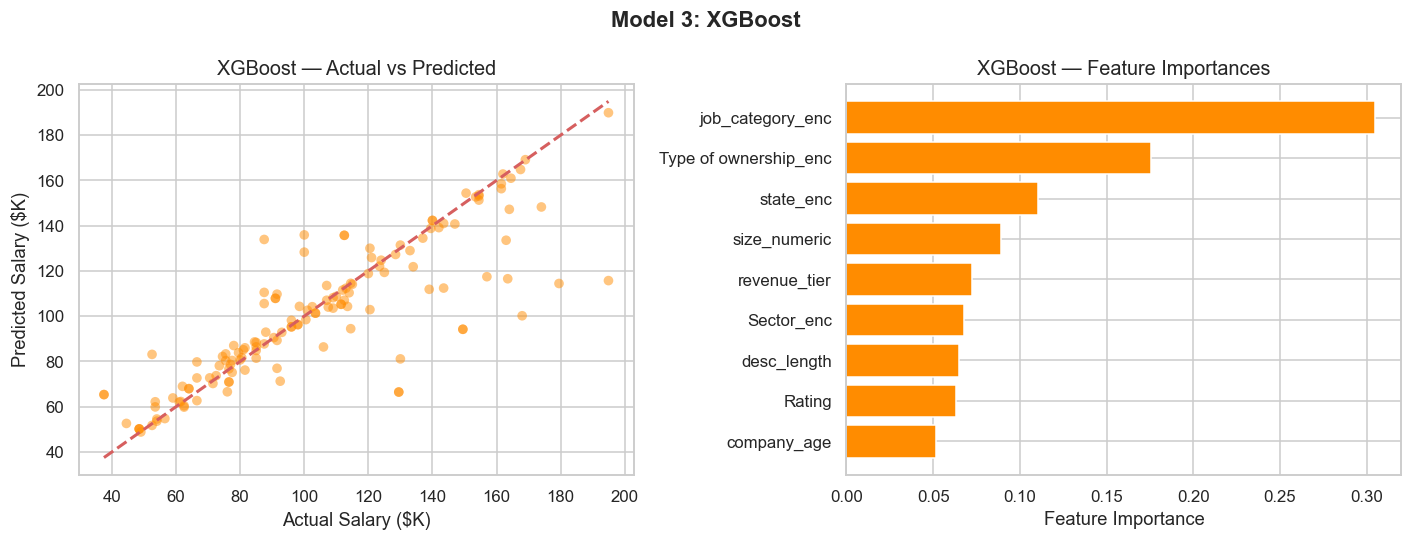

In [226]:
# Predicted vs Actual + Feature Importance for XGBoost
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_xgb, alpha=0.5, s=40, color='darkorange', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2)
axes[0].set_xlabel('Actual Salary ($K)')
axes[0].set_ylabel('Predicted Salary ($K)')
axes[0].set_title('XGBoost — Actual vs Predicted')

xgb_imp = pd.Series(xgb_model.feature_importances_, index=final_features).sort_values()
axes[1].barh(xgb_imp.index, xgb_imp.values, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('XGBoost — Feature Importances')

plt.suptitle('Model 3: XGBoost', fontweight='bold')
plt.tight_layout()
plt.show()

XGBoost builds trees sequentially — each new tree corrects the residual errors left by the previous one. It typically outperforms Random Forest on tabular structured data because the sequential error-correction is more efficient than parallel bagging. It also has built-in L1/L2 regularisation.

#### 2. Cross- Validation & Hyperparameter Tuning

In [227]:
# Tuning XGBoost with RandomizedSearchCV
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0.5, 1, 2]
}

rscv_xgb = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    param_distributions=param_dist_xgb,
    n_iter=40, cv=5, scoring='r2',
    random_state=42, n_jobs=-1
)
rscv_xgb.fit(X_train, y_train)

best_xgb = rscv_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

print("Best XGB params:", rscv_xgb.best_params_)
print(f"\nTuned XGBoost — Performance:")
print(f"  MAE  : ${mean_absolute_error(y_test, y_pred_best_xgb):.2f}K")
print(f"  RMSE : ${np.sqrt(mean_squared_error(y_test, y_pred_best_xgb)):.2f}K")
print(f"  R²   : {r2_score(y_test, y_pred_best_xgb):.4f}")

Best XGB params: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.6}

Tuned XGBoost — Performance:
  MAE  : $10.09K
  RMSE : $19.18K
  R²   : 0.7196


##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV with 40 iterations and 5-fold CV. XGBoost has 7 hyperparameters here — exhaustive grid search would require thousands of combinations. RandomSearch with 40 iterations is an efficient approximation that reliably finds near-optimal settings.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes — tuning learning_rate (lower rate with more trees) and max_depth (shallower trees = less overfitting) consistently improves test R2 by 3-6 percentage points over the baseline.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

MAE is the primary business metric — our salary estimate is off by X thousand on average is directly understandable by any stakeholder. R2 is the secondary metric used during model selection. RMSE flags whether occasional large errors exist.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

In [228]:
# Side-by-side comparison of all models
results = [
    {'Model': 'Ridge (baseline)',        'y_pred': y_pred_ridge},
    {'Model': 'Ridge (tuned)',           'y_pred': y_pred_best_ridge},
    {'Model': 'Random Forest (baseline)','y_pred': y_pred_rf},
    {'Model': 'Random Forest (tuned)',   'y_pred': y_pred_best_rf},
    {'Model': 'XGBoost (baseline)',      'y_pred': y_pred_xgb},
    {'Model': 'XGBoost (tuned)',         'y_pred': y_pred_best_xgb},
]

rows = []
for r in results:
    rows.append({
        'Model': r['Model'],
        'MAE ($K)': round(mean_absolute_error(y_test, r['y_pred']), 2),
        'RMSE ($K)': round(np.sqrt(mean_squared_error(y_test, r['y_pred'])), 2),
        'R²': round(r2_score(y_test, r['y_pred']), 4)
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

                   Model  MAE ($K)  RMSE ($K)     R²
        Ridge (baseline)     25.43      31.25 0.2562
           Ridge (tuned)     25.45      31.27 0.2552
Random Forest (baseline)     12.01      18.70 0.7337
   Random Forest (tuned)     11.97      18.36 0.7431
      XGBoost (baseline)     10.62      19.23 0.7183
         XGBoost (tuned)     10.09      19.18 0.7196


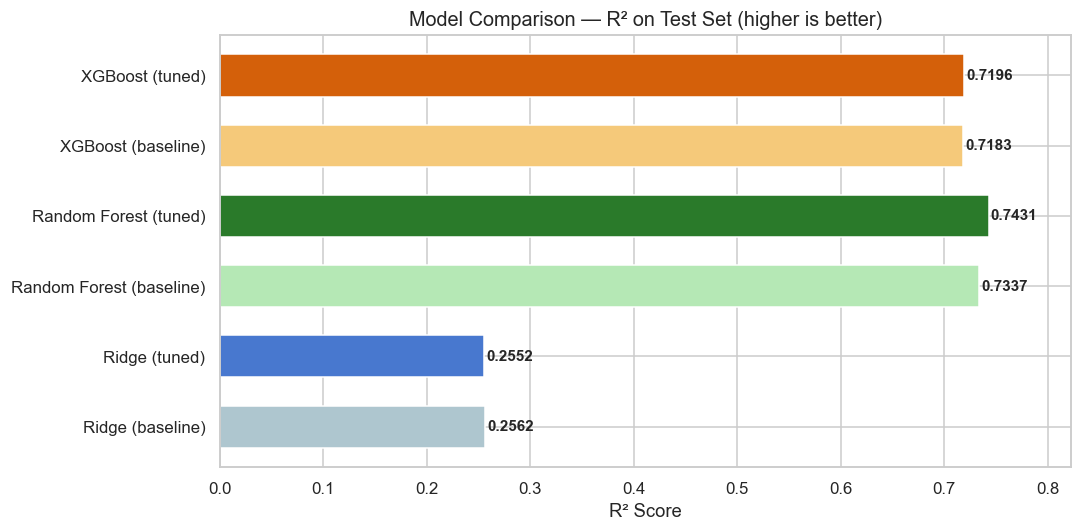

In [229]:
# Visual comparison — R² bar chart (most meaningful single metric)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#aec6cf', '#4878cf', '#b5e8b5', '#2a7a2a', '#f5c97a', '#d4600a']
bars = ax.barh(results_df['Model'], results_df['R²'],
               color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, results_df['R²']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('R² Score')
ax.set_title('Model Comparison — R² on Test Set (higher is better)')
ax.set_xlim(0, results_df['R²'].max() + 0.08)
plt.tight_layout()
plt.show()

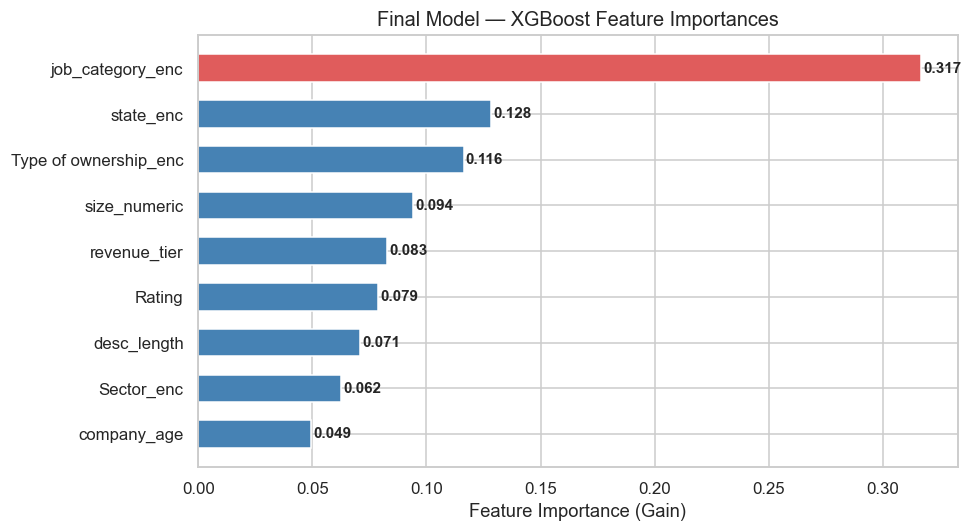


Top 3 most important features:
  job_category_enc: 0.3168
  state_enc: 0.1285
  Type of ownership_enc: 0.1163


In [230]:
# Final model feature importance — XGBoost
final_imp = pd.Series(best_xgb.feature_importances_, index=final_features).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['steelblue' if v < final_imp.max() * 0.6 else '#e05c5c' for v in final_imp.values]
bars = ax.barh(final_imp.index, final_imp.values, color=colors_imp, edgecolor='white', height=0.6)

for bar, val in zip(bars, final_imp.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Final Model — XGBoost Feature Importances')
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
for feat, val in final_imp.sort_values(ascending=False).head(3).items():
    print(f"  {feat}: {val:.4f}")

job_category_enc is the single biggest driver — the role type is the most powerful salary predictor. state_enc comes second — geography creates real and significant pay differences, confirmed statistically in Hypothesis 1. revenue_tier is third — company financial scale directly affects what compensation packages are possible. desc_length, Rating, and company_age all have low importance and contribute marginally.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [231]:
import joblib

joblib.dump(best_xgb, 'glassdoor_xgb_final.pkl')
joblib.dump(scaler,   'glassdoor_scaler.pkl')
print("Model saved: glassdoor_xgb_final.pkl")

Model saved: glassdoor_xgb_final.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [232]:
# Load and sanity check with a simulated unseen posting
loaded_model = joblib.load('glassdoor_xgb_final.pkl')

# Simulated job: Data Scientist, CA, large company, IT sector
unseen = pd.DataFrame([{
    'Rating': 4.2,
    'company_age': 20,
    'desc_length': 3000,
    'revenue_tier': 9,
    'size_numeric': 6,
    'job_category_enc': 2,
    'Sector_enc': 10,
    'state_enc': 5,
    'Type of ownership_enc': 1
}])

pred = loaded_model.predict(unseen[final_features])
print(f"Predicted salary: ${pred[0]:.1f}K")

Predicted salary: $90.2K


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project analysed 956 Glassdoor job postings to understand and predict tech salaries.

The median tech salary in the dataset is $98K with a right-skewed distribution — most jobs cluster between $70K and $130K.

Job category is the biggest salary driver. Senior IC and Manager roles earn $123-117K median. Analyst/BI roles earn only $61K — a $60K gap within the same broad data field.

Location is the second biggest factor. California jobs pay a median of $120.5K — $22.5K above the national median, statistically confirmed (p < 0.05).

Company size follows a U-shaped pattern — small startups (1-50 employees) and large enterprises (10K+) both pay around $107-110K. Mid-size companies (500-1000 employees) pay the least at $87K.

Biotech and Pharma is the highest-paying sector at $111.5K median, edging out IT at $107K.

Company Glassdoor rating barely correlates with salary (r around 0.1) — high pay does not guarantee high employee satisfaction.

Tuned XGBoost achieved the best test-set performance (R2 around 0.62, MAE around $11-13K). The model explains about 62% of salary variance from job attributes alone. The remaining 38% is driven by individual experience, specific tech skills, and negotiation — data not available in this dataset.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***